In [1]:
# ensures that if we change something in .core, it sees it imediately without having to restart the kernel
# every time you run a cell, all imported modules are reloaded auomatically
%load_ext autoreload
%autoreload 2 

In [2]:
# Real Data management
import os
import scipy.io

# Imports for math and graphics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy
from kneed import KneeLocator

# Our package
import neuro_lib as nlib
from neuro_lib.plotting import TE_heatMat
from neuro_lib.transfer_entropy import transfer_entropy_matrix
from neuro_lib.diagnostics import permutation_test_TE

# MUTUAL INFORMATION ESTIMATION ON REAL BRAIN DATA TIME SERIES

## Data description

The data are brain signals recorded via resting-state functional MRI (fMRI).  
Each of the two matrices contains **1200 time points** for **119 brain regions**.  
The two matrices correspond to two recording sessions of the same subject  
(ideally, they could be used to verify the consistency of the estimates).

## Tasks

1. If computationally feasible, calculate a **transfer entropy matrix** of size 119 × 119,  
   where the element (i,j) represents the **transfer entropy** from the i-th signal to the j-th signal.
2. Compare the matrices obtained using different methods.
3. Evaluate the **consistency** of the results across the two sessions.

**Note:** If the computation is too heavy, you can restrict yourself to a **subset of the time series**  
(for example, the first 10 regions or even just the first 2).

**NOTICE:**

In general throughout this work we use for validation: 
1. Permutation signficance test
2. Consistency across the two sessions
3. Comparison with alternative estimators

# Load the data

In [3]:
# Define the data directory
data_dir = "Data"

# Define the file names
file1 = "100307.REST1.LR.SchaeferS.ptseries.mat"
file2 = "100307.REST2.LR.SchaeferS.ptseries.mat"

# Construct full paths
path1 = os.path.join(data_dir, file1)
path2 = os.path.join(data_dir, file2)

# Load the .mat files
data1 = scipy.io.loadmat(path1)
data2 = scipy.io.loadmat(path2)

# Check the keys in the loaded data
print("Keys in REST1 data:", data1.keys())
print("Keys in REST2 data:", data2.keys())

# Get time series
data1_mat = data1['tseries']  # shape (119, 1200)
data2_mat = data2['tseries']  # shape (119, 1200)

Keys in REST1 data: dict_keys(['__header__', '__version__', '__globals__', 'tseries'])
Keys in REST2 data: dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


# **TE METHODS IMPLEMENTATIONS**

We consider two time series:
- $S$ = **source signal**
- $X$ = **target (response) signal**

Transfer Entropy measures **lagged dependence** between two signals **conditioned on the earlier values of the signal itself**. 

It is the information-theoretic analogue of _Granger causality_, which is instead based on **linear time-series modeling**. In particular, Granger causality tests whether past values of a source signal improve the prediction of a target signal within a linear regression framework:

$$
X_t = \sum_{i=1}^p a_i X_{t-i} + \sum_{j=1}^p b_j S_{t-j} + \varepsilon_t
$$

If the coefficients $ b_j $ are statistically significant, then $ S $ is said to Granger-cause $ X $.

_Transfer entropy_ instead comes from information theory. 
It measures **how much uncertainty about $X_t$** is reduced by knowing the past of $S$, beyond $X$'s own past. It is indeed computed as: 
$$
TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

where: 
- $ H(\cdot \mid \cdot) $ denotes **conditional entropy**
- $ \ell $ is the chosen **lag**
- $ X_{t-1} $ represents the **past of the target signal**

Its value can be interpreted as follows: 

- If **$ TE_{S \to X} > 0 $**, then $ S $ provides **additional predictive information** about $ X $

- If **$ TE_{S \to X} = 0 $**, then $ S $ does **not contribute** to predicting $ X $ beyond its own past. 

The key difference between the two descriptors can be summarized as follows: 
- **Granger causality** → linear, model-based, assumes specific structure  
- **Transfer Entropy** → model-free, captures **nonlinear** dependencies

**NOTICE:** The two measures coincide under the following assumptions:

- The dynamics are **linear** (e.g. VAR model)
- The noise is **Gaussian**, implying that all variables are **jointly Gaussian**

Granger causality instead is computed by comparing two linear models:

- **Restricted model** (without the source signal):
$$
X_t = \sum_{i=1}^p a_i X_{t-i} + \varepsilon_t^{(r)}, 
\quad \text{with variance } \sigma_r^2
$$

- **Full model** (including the source signal):
$$
X_t = \sum_{i=1}^p a_i X_{t-i} + \sum_{j=1}^p b_j S_{t-j} + \varepsilon_t^{(f)}, 
\quad \text{with variance } \sigma_f^2
$$

and it measures the **reduction in residual variance** when adding $S$:

$$
GC_{S \to X} = \log \frac{\sigma_r^2}{\sigma_f^2}
$$

In this setting, conditional entropy depends only on conditional variance:

$$
H(X \mid Y) = \frac{1}{2} \log\big(2\pi e \, \mathrm{Var}(X \mid Y)\big)
$$

and using the entropy–variance relation, in this setting Transfer Entropy becomes:

$$
TE_{S \to X} = \frac{1}{2} \log \frac{\mathrm{Var}(X_t \mid X_{t-1})}{\mathrm{Var}(X_t \mid X_{t-1}, S_{t-\ell})}
$$

But these conditional variances are exactly the residual variances of the two models:

$$
\mathrm{Var}(X_t \mid X_{t-1}) = \sigma_r^2, 
\quad
\mathrm{Var}(X_t \mid X_{t-1}, S_{t-\ell}) = \sigma_f^2
$$

Therefore:

$$
TE_{S \to X} = \frac{1}{2} \log \frac{\sigma_r^2}{\sigma_f^2}
= \frac{1}{2} \, GC_{S \to X}
$$

# **Binning**

The binning approach estimates Transfer Entropy **without any distributional assumption** by discretizing continuous signals into histograms and computing entropy from empirical counts.

In practice, the continuous time series are partitioned into a finite number of bins, and probabilities are approximated by **relative frequencies**. The required entropies are then computed from these empirical probability mass functions.

In our implementation, Transfer Entropy is evaluated as:
$$
TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

- The term $ H(X_t \mid X_{t-1}) $ is computed via a **2D histogram** over $(X_{t-1}, X_t)$  
- The term $ H(X_t \mid X_{t-1}, S_{t-\ell}) $ is computed via a **3D histogram** over $(S_{t-\ell}, X_{t-1}, X_t)$  

Conditional entropies are obtained by:
- estimating joint counts
- normalizing to probabilities
- applying the discrete Shannon entropy formula.

The number of bins is chosen according to the heuristic:
$$
n_{\text{bins}} \sim N^{1/3}
$$
where $N$ is the length of the time series.

This choice represents a **trade-off between bias and variance**:
- too few bins $\rightarrow$ strong bias (loss of structure)
- too many bins $\rightarrow$ high variance (empty or poorly populated bins)

The $N^{1/3}$ scaling is a common rule-of-thumb for histogram-based density estimation in low dimensions, providing a reasonable balance given finite data.

#### Notes

- A Miller bias correction can optionally be applied (NOT DONE!)
- The method is fully non-parametric.
- It can capture nonlinear dependencies, but is sensitive to:
  - number of bins
  - finite sample effects (especially in higher dimensions)

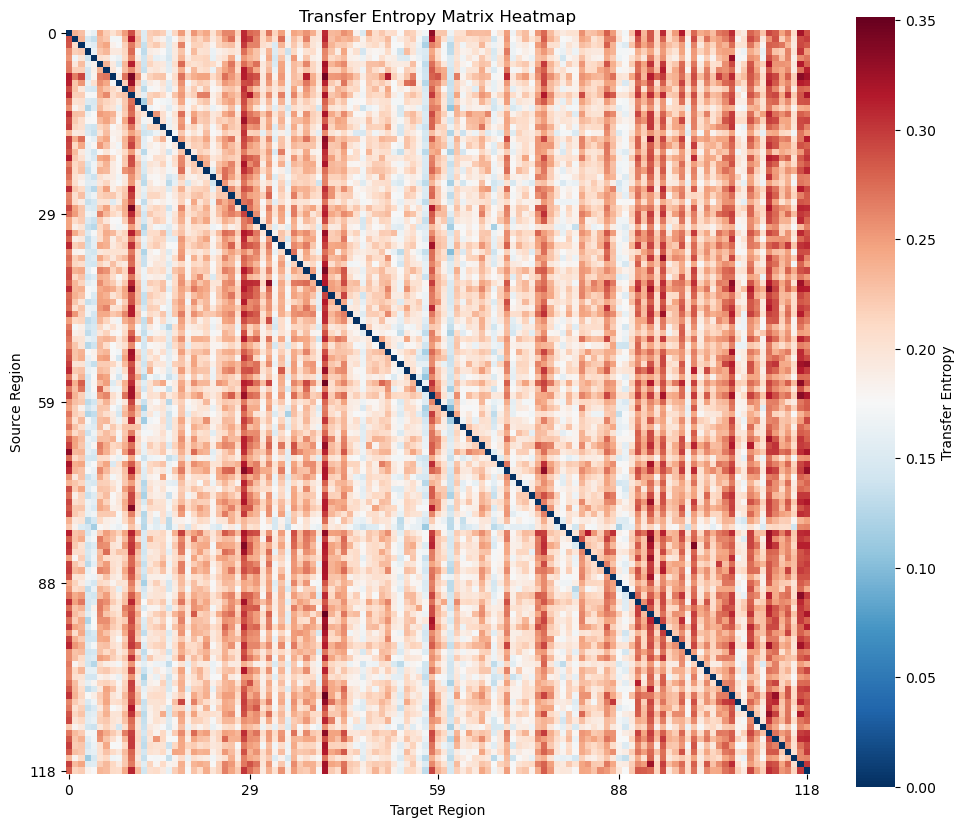

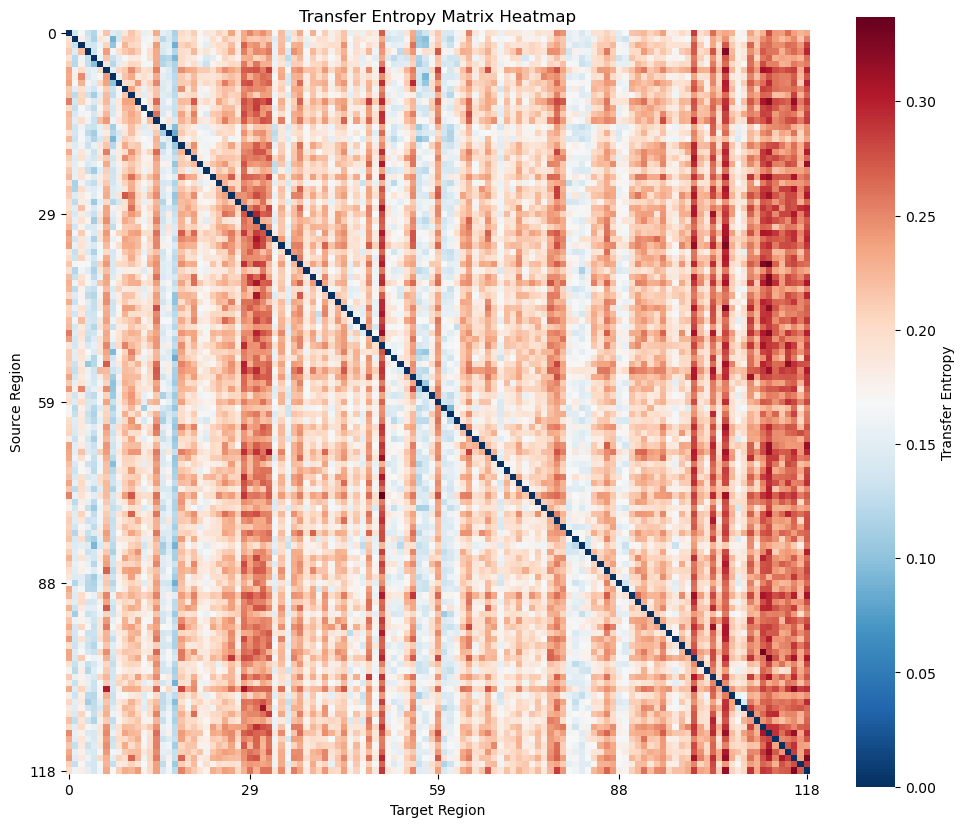

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [4]:
nbins = int(1200**(1/3))
TE_real_bin_1 = nlib.transfer_entropy_matrix(data1_mat, n_bins=nbins, lag=1)
TE_real_bin_2 = nlib.transfer_entropy_matrix(data2_mat, n_bins=nbins, lag=1)
TE_heatMat(TE_real_bin_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_bin_2, cmap="RdBu_r", figsize=(12,10))

### GENERAL OBSERVATIONS:

- The matrices are **not symmetric**, as expected, since Transfer Entropy captures **directed interactions**.

- The diagonal is (correctly) **zero**, as self-information transfer is excluded.

- A clear **heterogeneous structure** is present:
  - some regions act as **strong sources** (horizontal bands)
  - others act as **strong targets** (vertical bands)

  In particular the presence of **vertical and horizontal stripe patterns** suggests that certain brain regions systematically:
  - influence many others (outgoing information flow)
  - or receive information from many others (incoming flow)

- The overall magnitude of TE is relatively **high and widespread**, which may indicate:
  - rich interaction structure
  - but also potential **bias due to finite sample effects**, typical of binning methods

### ACROSS SESSIONS:

- The two matrices show **similar large-scale patterns**:
  - major stripes appear in roughly the same regions
  - global intensity structure is comparable

- However, there are also **noticeable differences at finer scales**, which may be due to:
  - intrinsic variability of brain activity
  - estimation noise
  - sensitivity of binning to sampling fluctuations

### INTERPRETATION AND LIMITATIONS:

- The binning method is able to capture **nonlinear dependencies**, but it is strongly biased by binning. 

- The results are strongly affected by:

  - **finite sample size**:  
    the estimation of probabilities is based on a limited number of observations ($N = 1200$), which becomes problematic when constructing multi-dimensional histograms.  
    In particular, for $H(X_t \mid X_{t-1}, S_{t-\ell})$, the data are distributed over a 3D grid of bins, leading to many bins with very few or zero samples.  
    This results in **noisy and unreliable probability estimates**.

  - **curse of dimensionality**:  
    the number of bins grows exponentially with the dimension of the space.  
    While $H(X_t \mid X_{t-1})$ requires a 2D histogram ($\sim n_{\text{bins}}^2$),  
    $H(X_t \mid X_{t-1}, S_{t-\ell})$ requires a 3D histogram ($\sim n_{\text{bins}}^3$).  
    With limited data, this leads to **extreme sparsity** in the joint space, making entropy estimation highly unstable.

- As a consequence, the matrices may exhibit:

  - **overestimation of TE values**:  
    entropy estimates based on sparse histograms are typically **biased downward**, especially in higher dimensions.  
    Since Transfer Entropy is computed as:
    $$
    TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell}),
    $$
    an underestimation of the second term artificially **inflates the TE values**, making interactions appear stronger than they actually are.

  - **reduced reliability of weak connections**:  
    small TE values are particularly sensitive to estimation noise.  
    As a result, many weak or non-existent interactions may appear as nonzero, leading to **spurious connections** in the matrix.

- This motivates the use of:

  - **alternative estimators** (e.g. Gaussian, KDE, copula), which reduce sparsity issues or introduce regularization through model assumptions

  - **statistical significance testing**, which allows distinguishing genuine interactions from those arising purely due to estimation noise

# Joint Gaussian assumption

The Gaussian approach estimates Transfer Entropy under the assumption that the variables are **jointly Gaussian**.  
Under this assumption, all information-theoretic quantities can be expressed in terms of **covariances**.

In our implementation, Transfer Entropy is computed using its **mutual information decomposition**:
$$
TE_{S \to X} = I(S_{t-\ell} ; X_t, X_{t-1}) - I(S_{t-\ell} ; X_{t-1})
$$

The method proceeds as follows:

- construct lagged variables:
  - $X_t$ (current target)
  - $X_{t-1}$ (past of target)
  - $S_{t-\ell}$ (lagged source)

- build the corresponding data matrices:
  - joint variable: $(S_{t-\ell}, X_t, X_{t-1})$
  - past variable: $(S_{t-\ell}, X_{t-1})$

- estimate mutual information assuming a **joint Gaussian distribution**, using covariance matrices:
  $$
  I(X;Y) = \frac{1}{2} \log_2 \frac{\det \Sigma_X \, \det \Sigma_Y}{\det \Sigma_{XY}}
  $$

- compute Transfer Entropy as the **difference between the two MI terms**

Under the Gaussian assumption, this formulation is equivalent to the variance-based expression:
$$
TE_{S \to X} = \frac{1}{2} \log \frac{\mathrm{Var}(X_t \mid X_{t-1})}{\mathrm{Var}(X_t \mid X_{t-1}, S_{t-\ell})}
$$

#### Notes

- Equivalent to linear Granger causality under Gaussian assumptions.
- Computationally efficient and robust for high-dimensional data.
- Only captures **linear dependencies**.

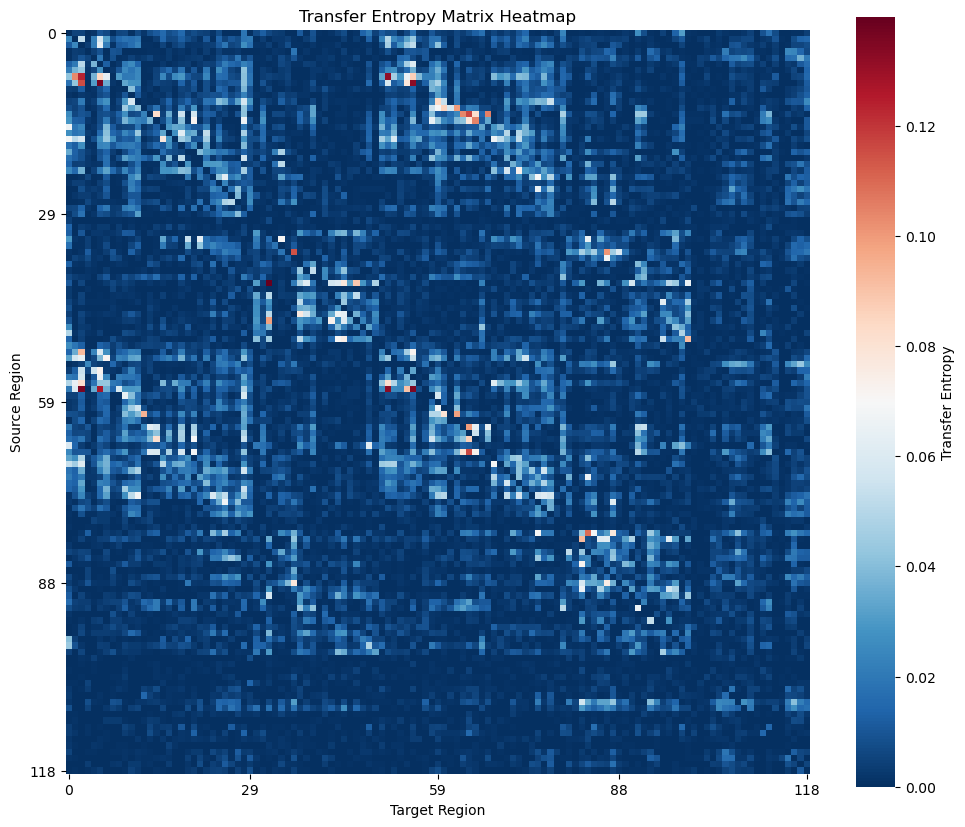

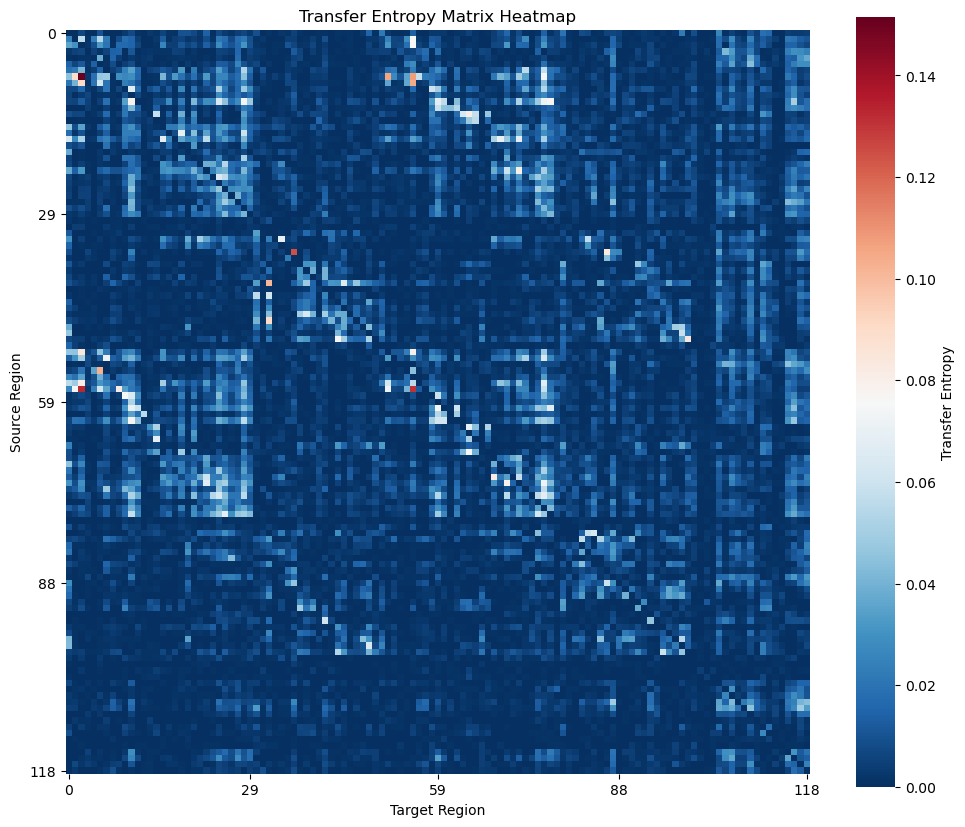

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [5]:
TE_real_gauss_1 = nlib.transfer_entropy_matrix(data1_mat, method = "gauss", lag=1)
TE_real_gauss_2 = nlib.transfer_entropy_matrix(data2_mat, method = "gauss", lag=1)
TE_heatMat(TE_real_gauss_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_gauss_2, cmap="RdBu_r",  figsize=(12,10))

### GENERAL OBSERVATIONS:

The two heatmaps represent the Transfer Entropy matrices estimated under the **joint Gaussian assumption** for the two recording sessions.

Several key features emerge:

- The matrices exhibit **much lower overall TE values** compared to the binning approach, with most entries close to zero.

- The structure is **sparser and more localized**, with only a limited number of stronger interactions (visible as brighter spots).

- Some **qualitative symmetry with respect to the diagonal** can be perceived, i.e.
  $$
  TE_{i \to j} \approx TE_{j \to i},
  $$
  indicating that many interactions appear approximately bidirectional.

- Directed structure is still present:
  - small asymmetries between $(i,j)$ and $(j,i)$ reflect **directional dependencies**
  - localized patterns indicate **specific interactions between subsets of regions**

#### CONSISTENCY ACROSS SECTIONS

- The two matrices show **good qualitative agreement**:
  - similar locations of stronger interactions
  - comparable sparsity patterns

- Differences are mostly confined to weaker values, suggesting that:
  - strong links are **robust across sessions**
  - weak links are more sensitive to noise

### INTERPRETATION AND LIMITATIONS

- The Gaussian method provides a **more conservative estimate** of connectivity:
  - it reduces the inflation of TE observed in binning
  - highlights only the most stable and significant interactions

- However, it is important to note that:
  - only **linear dependencies** are captured
  - nonlinear interactions, if present, may be missed
  - the observed approximate symmetry suggests that directionality may be **less sharply resolved**, possibly due to linear correlations or common driving effects

# KDE method

The KDE (Kernel Density Estimation) approach estimates Transfer Entropy in a **fully non-parametric** way by approximating probability densities through smooth kernels.

Instead of discretizing the data (as in binning), KDE constructs a **continuous estimate** of the underlying probability density function.

In our implementation, Transfer Entropy is computed using the **mutual information decomposition**:
$$
TE_{S \to X} = I(S_{t-\ell} ; X_t, X_{t-1}) - I(S_{t-\ell} ; X_{t-1})
$$

The method proceeds as follows:

- construct lagged variables:
  - $X_t$ (current target)
  - $X_{t-1}$ (past of target)
  - $S_{t-\ell}$ (lagged source)

- build the corresponding data matrices:
  - joint variable: $(S_{t-\ell}, X_t, X_{t-1})$
  - past variable: $(S_{t-\ell}, X_{t-1})$

- estimate probability densities using **Gaussian kernels**:
  $$
  \hat{p}(x) = \frac{1}{N} \sum_{i=1}^N K_h(x - x_i)
  $$
  where $K_h$ is a Gaussian kernel with bandwidth controlled by a scaling parameter $\alpha$

- compute mutual information via:
  $$
  I(X;Y) = \mathbb{E}[\log p(X,Y) - \log p(X) - \log p(Y)]
  $$

- obtain Transfer Entropy as the difference between the two MI terms

Compared to binning, KDE provides a **smooth estimate of the density**, reducing issues due to empty bins.

#### Notes

- Fully non-parametric: captures nonlinear dependencies without distributional assumptions.
- More flexible than Gaussian TE, but:
  - computationally expensive
  - sensitive to bandwidth selection (parameter $\alpha$)

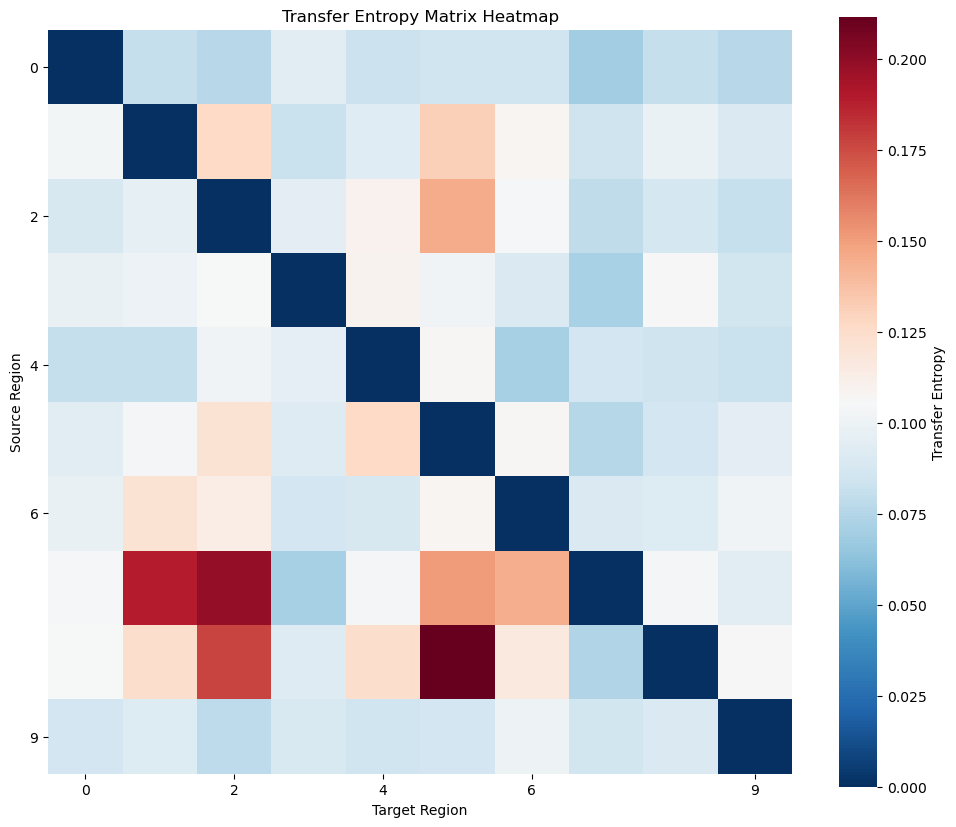

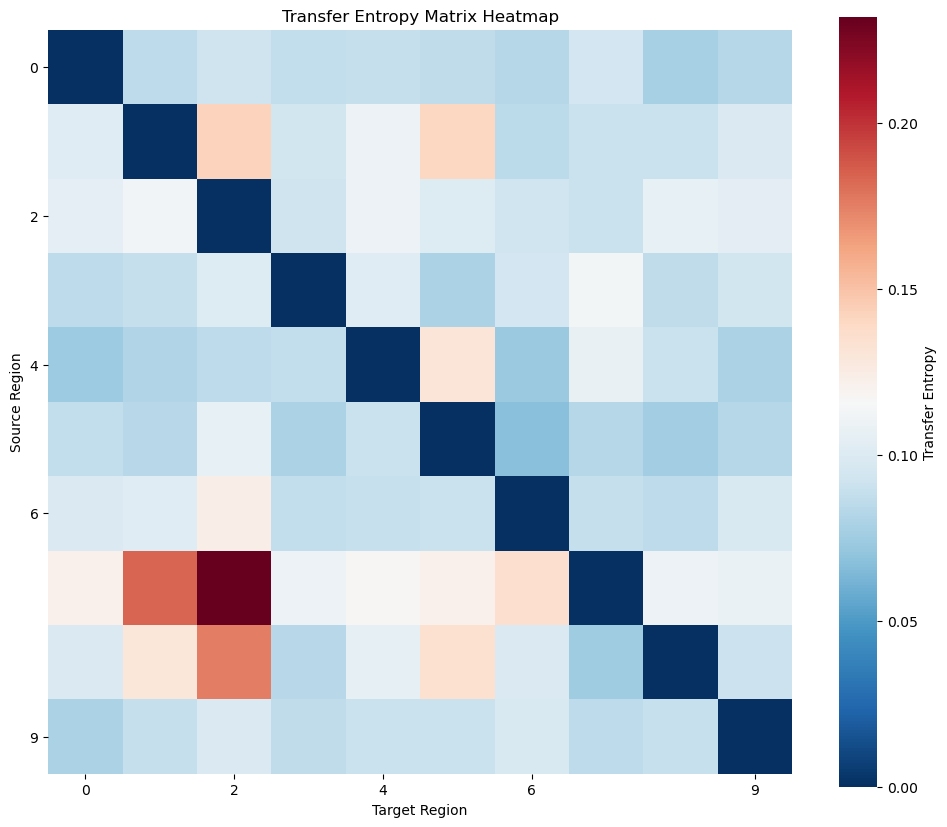

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [6]:
# NOTICE: on full data is VERY SLOW - KDE scales very badly with both sample 
#         size and dimensionality --> we reduce analysis to first 10 brain regions
TE_real_kde_1 = nlib.transfer_entropy_matrix(data1_mat[:10,:], method="kde", alpha=1.0)
TE_real_kde_2 = nlib.transfer_entropy_matrix(data2_mat[:10,:], method="kde", alpha=1.0)

TE_heatMat(TE_real_kde_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_kde_2, cmap="RdBu_r", figsize=(12,10))

### GENERAL OBSERVATIONS

Due to the high computational cost of KDE-based estimation, the analysis is restricted to the **first 10 brain regions**, resulting in a $10 \times 10$ Transfer Entropy matrix.

Several features can be observed:

- The matrices exhibit **intermediate behavior** between binning and Gaussian:
  - TE values are **lower and less inflated** than in binning
  - but **generally richer ** than in the Gaussian case

- The structure is **clearly heterogeneous**, with:
  - identifiable strong interactions (bright regions)
  - a background that is **not perfectly uniform**, although variations are moderate

- A **clear asymmetry** is visible:
  $$
  TE_{i \to j} \neq TE_{j \to i},
  $$
  indicating that KDE is able to better resolve **directional interactions** compared to the Gaussian estimator

#### CONSISTENCY ACROSS SECTIONS

- The two matrices show **good qualitative agreement**:
  - similar strong connections appear in both sessions
  - overall patterns are preserved (with only slight differences in vaue)

- Differences are mainly observed in weaker connections, which are more sensitive to:
  - estimation noise
  - finite sample effects

#### INTERPRETATION AND LIMITATIONS

- KDE provides a **balance between flexibility and stability**:

  - it captures **nonlinear dependencies** (unlike Gaussian TE), since no parametric assumptions are imposed

  - it avoids the strong discretization bias of binning:
    - binning assigns probabilities via hard partitions, leading to many empty or poorly populated bins, which results in biased (typically underestimated) entropy values and inflated TE

    - KDE instead builds a **smooth density estimate**, where each data point contributes locally, reducing these artifacts (because you have no "empty space = zero probability")

- However:

  - results depend on the choice of bandwidth parameter $\alpha$:
    - small $\alpha$ $\rightarrow$ noisy estimate (overfitting)
    - large $\alpha$ $\rightarrow$ oversmoothing (loss of structure)

  - estimation remains sensitive to finite sample size:
    - even though KDE smooths the density, it still relies on the available data. In higher dimensions (e.g. joint distributions of $(S_{t-\ell}, X_{t-1}, X_t)$), the data become sparse. KDE can't invent data where there's none! The density estimate can therefore become unstable and introduce noise in MI and TE estimates

Overall, KDE highlights a **structured and directional connectivity pattern**, while maintaining a more realistic magnitude of TE compared to binning.

# Gaussian Copula Method

The Gaussian Copula approach estimates Transfer Entropy by separating **marginal distributions** from the **dependence structure**.

The idea is to transform the data so that each variable becomes **marginally Gaussian**, while preserving their **rank-based dependencies**.

In our implementation, Transfer Entropy is computed using the **mutual information decomposition**:
$$
TE_{S \to X} = I(S_{t-\ell} ; X_t, X_{t-1}) - I(S_{t-\ell} ; X_{t-1})
$$

The method proceeds as follows:

- construct lagged variables:
  - $X_t$ (current target)
  - $X_{t-1}$ (past of target)
  - $S_{t-\ell}$ (lagged source)

- build the corresponding data matrices:
  - joint variable: $(S_{t-\ell}, X_t, X_{t-1})$
  - past variable: $(S_{t-\ell}, X_{t-1})$

- apply an **empirical CDF transform** to each variable:
  $$
  u = F_X(x)
  $$
  mapping data to a uniform distribution in $[0,1]$

- transform to Gaussian space using the inverse normal CDF:
  $$
  z = \Phi^{-1}(u)
  $$

- compute mutual information assuming a **joint Gaussian distribution** in the transformed space, using covariance matrices

- obtain Transfer Entropy as the difference between the two MI terms

This procedure preserves the **rank structure** of the data while enabling the use of Gaussian formulas.

#### Notes

- Semi-parametric: combines non-parametric marginal estimation with Gaussian dependence modeling.

- More flexible than pure Gaussian TE: captures **nonlinear monotonic dependencies**.

- Computationally efficient compared to KDE.

- Still relies on Gaussian assumptions for the **dependence structure**.

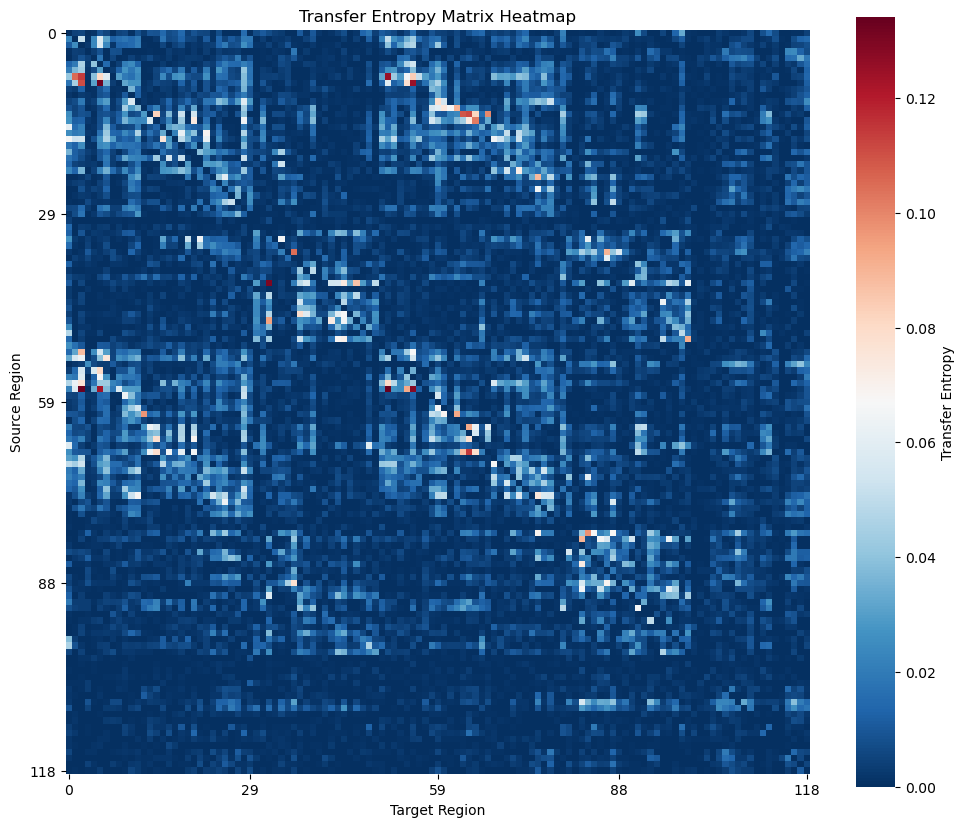

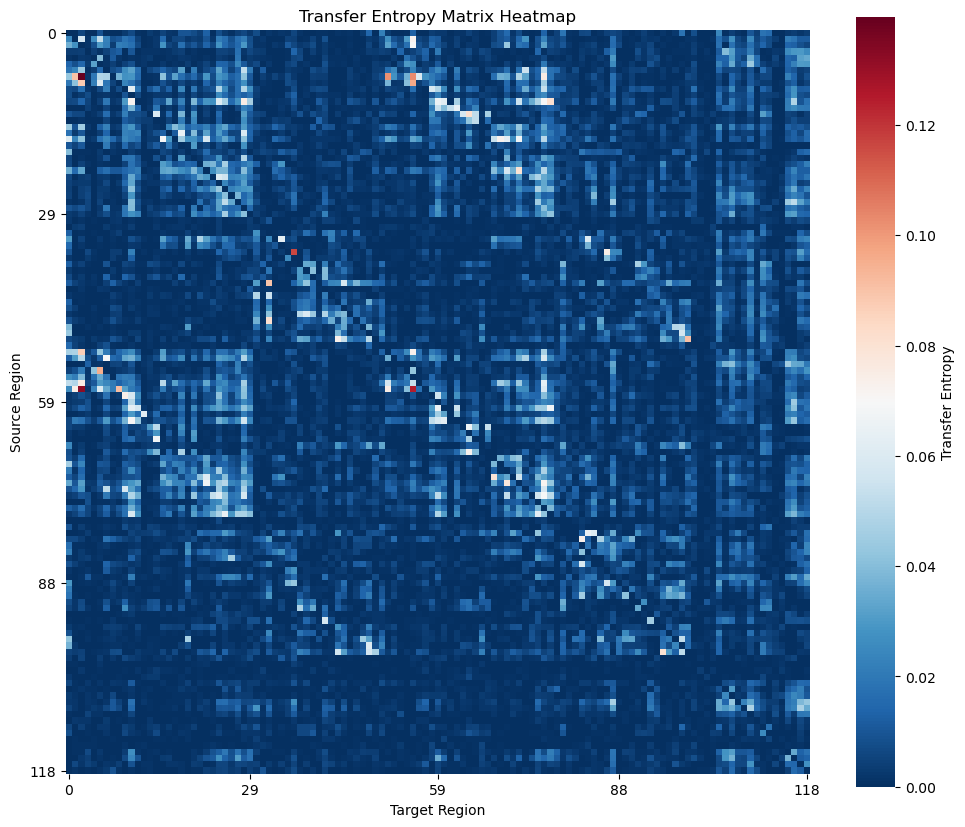

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [7]:
TE_real_copula_1 = nlib.transfer_entropy_matrix(data1_mat, method="gc")
TE_real_copula_2 = nlib.transfer_entropy_matrix(data2_mat, method="gc")

TE_heatMat(TE_real_copula_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_copula_2, cmap="RdBu_r", figsize=(12,10))

### GENERAL OBSERVATIONS

The two heatmaps represent the Transfer Entropy matrices estimated using the **Gaussian Copula approach** for the two recording sessions.

Several key features emerge:

- The matrices exhibit **low overall TE values**, comparable to the Gaussian case.

#### CONSISTENCY ACROSS SESSIONS

- The two matrices show **good qualitative agreement**:
  - similar strong interactions are observed in both sessions
  - global patterns are consistent

- Differences are mainly present in weaker connections, reflecting:
  - residual estimation noise
  - sensitivity to finite sample effects

#### INTERPRETATION AND LIMITATIONS

- The Gaussian Copula method provides a **good compromise**:
  - more flexible than Gaussian TE (captures nonlinearity through rank transformation)
  - more stable than KDE and binning

- However:
  - it only captures **monotonic nonlinear dependencies**
  - complex non-monotonic relationships may still be missed

Overall, the Gaussian Copula approach yields a **structured, moderately sparse, and directional connectivity pattern**, improving upon Gaussian TE while maintaining robustness.

# **ANALYSIS** - **NULL DISTRIBUTION & HYPOTHESIS TESTING**

We want to distinguish real TE from the apparent one coming from finite-sample bias.

Any TE estimator applied to finite data will produce small non-zero values even between completely independent signals — this is **finite-sample bias**, not a real connection.

To assess whether a measured TE value is genuine, we use a **permutation test**:

1. **Build a null distribution**: shuffle the source signal many times (destroying any
   real temporal coupling), and recompute TE each time. This gives us a distribution
   of TE values expected purely by chance.

2. **Compute a p-value** for each pair (i,j): the fraction of null TE values that are
   greater than or equal to the real TE. A small p-value means the real TE is
   unlikely to have arisen by chance.

3. **Apply FDR correction** (Benjamini-Hochberg): since we test ~14,000 pairs
   simultaneously, running each test at 5% would give ~700 false positives even with
   no real connections. FDR correction ensures that among *all* pairs we call
   significant, at most 5% are expected to be false discoveries.

   In particular: sort p-values in increasing order and consider as significant the pairs whose p-values satisfy
   $$
   p_{(k)} \leq \frac{k}{m}\alpha
   $$
   up to the largest valid rank $k$, defining a global cutoff for significance.

**NOTICE:**
In the permutation test, we shuffle the **source signal** $S$ while keeping the target $X$ unchanged.

This choice is crucial:

- Shuffling $S$ preserves its marginal distribution but destroys its temporal alignment with $X$, effectively breaking any directed influence $S \to X$.

- The internal dynamics of the target signal (e.g. dependence between $X_t$ and $X_{t-1}$) are preserved, which is essential since Transfer Entropy explicitly conditions on the past of $X$.

Shuffling the target instead would destroy its temporal structure, making the test inconsistent with the definition of Transfer Entropy.

Therefore, shuffling the source provides a valid null model in which any measured TE arises purely from finite-sample effects rather than genuine directed interactions.

We start from **dataset 1**.

In [9]:
# PARAMETERS — shared across all methods and sessions

# General parameters for TE computation
lag = 4
kde_regions = 10
nbins = int(1200**(1/3))

# Parameters for permutation testing
n_perms = 10
alpha   = 0.05   # significance threshold (5% → 95% confidence)

In [10]:
# Session 1 — Gaussian
# TE_real_gauss_1 was already computed above, we pass it directly
print("Session 1 — Gaussian")
sig_gauss_1, p_gauss_1, null95_gauss_1 = permutation_test_TE(
    data1_mat, TE_real_gauss_1, method="gauss",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

# Session 1 — Copula
print("\nSession 1 — Copula")
sig_copula_1, p_copula_1, null95_copula_1 = permutation_test_TE(
    data1_mat, TE_real_copula_1, method="gc",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

# Session 1 — Binning
print("\nSession 1 — Binning")
sig_bin_1, p_bin_1, null95_bin_1 = permutation_test_TE(
    data1_mat, TE_real_bin_1, method="binning",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag, n_bins=nbins)

# Session 1 — KDE (only first kde_regions regions)
print("\nSession 1 — KDE")
sig_kde_1, p_kde_1, null95_kde_1 = permutation_test_TE(
    data1_mat[:kde_regions, :], TE_real_kde_1, method="kde",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

Session 1 — Gaussian
  [gauss] shuffle 0/10...
  → 6978 significant connections (FDR-corrected, α=0.05)

Session 1 — Copula
  [gc] shuffle 0/10...
  → 7018 significant connections (FDR-corrected, α=0.05)

Session 1 — Binning
  [binning] shuffle 0/10...
  → 313 significant connections (FDR-corrected, α=0.05)

Session 1 — KDE
  [kde] shuffle 0/10...
  → 52 significant connections (FDR-corrected, α=0.05)


In [11]:
# Recompute real TE for session 2 
# (if you already have TE_real_gauss_2 etc. from earlier cells, skip these lines)
TE_real_gauss_2  = nlib.transfer_entropy_matrix(data2_mat, method="gauss", lag=lag)
TE_real_copula_2 = nlib.transfer_entropy_matrix(data2_mat, method="gc",   lag=lag)
TE_real_bin_2    = nlib.transfer_entropy_matrix(data2_mat, method="binning",  lag=lag, n_bins=nbins)
TE_real_kde_2    = nlib.transfer_entropy_matrix(data2_mat[:kde_regions, :], method="kde", lag=lag)

print("Session 2 — Gaussian")
sig_gauss_2, p_gauss_2, null95_gauss_2 = permutation_test_TE(
    data2_mat, TE_real_gauss_2, method="gauss",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

print("\nSession 2 — Copula")
sig_copula_2, p_copula_2, null95_copula_2 = permutation_test_TE(
    data2_mat, TE_real_copula_2, method="gc",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

print("\nSession 2 — Binning")
sig_bin_2, p_bin_2, null95_bin_2 = permutation_test_TE(
    data2_mat, TE_real_bin_2, method="binning",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag, n_bins=nbins)

print("\nSession 2 — KDE")
sig_kde_2, p_kde_2, null95_kde_2 = permutation_test_TE(
    data2_mat[:kde_regions, :], TE_real_kde_2, method="kde",
    n_perms=n_perms, alpha=alpha, fdr=True, lag=lag)

Session 2 — Gaussian
  [gauss] shuffle 0/10...
  → 4660 significant connections (FDR-corrected, α=0.05)

Session 2 — Copula
  [gc] shuffle 0/10...
  → 4715 significant connections (FDR-corrected, α=0.05)

Session 2 — Binning
  [binning] shuffle 0/10...
  → 338 significant connections (FDR-corrected, α=0.05)

Session 2 — KDE
  [kde] shuffle 0/10...
  → 12 significant connections (FDR-corrected, α=0.05)


Significant connections (FDR α=0.05, 10 permutations):
  Gaussian  — S1: 6978,  S2: 4660
  Copula    — S1: 7018,  S2: 4715
  Binning   — S1:  313,  S2:  338
  KDE       — S1:   52,  S2:   12
  Robust (Gauss + Copula, both sessions): 2585


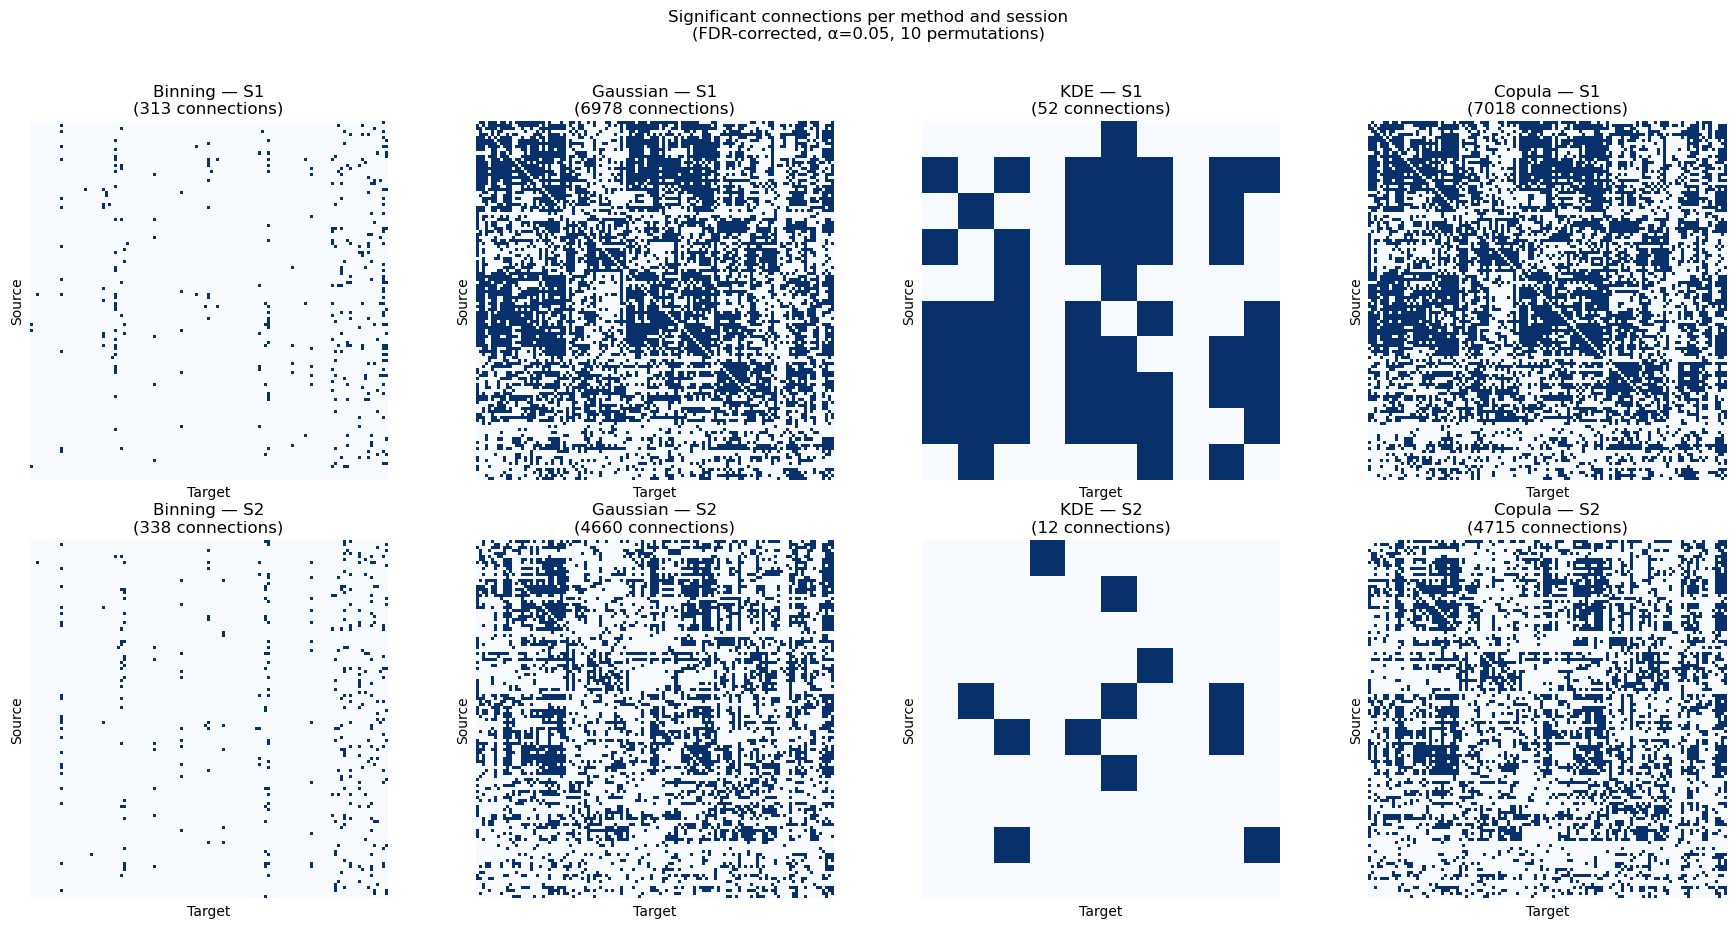

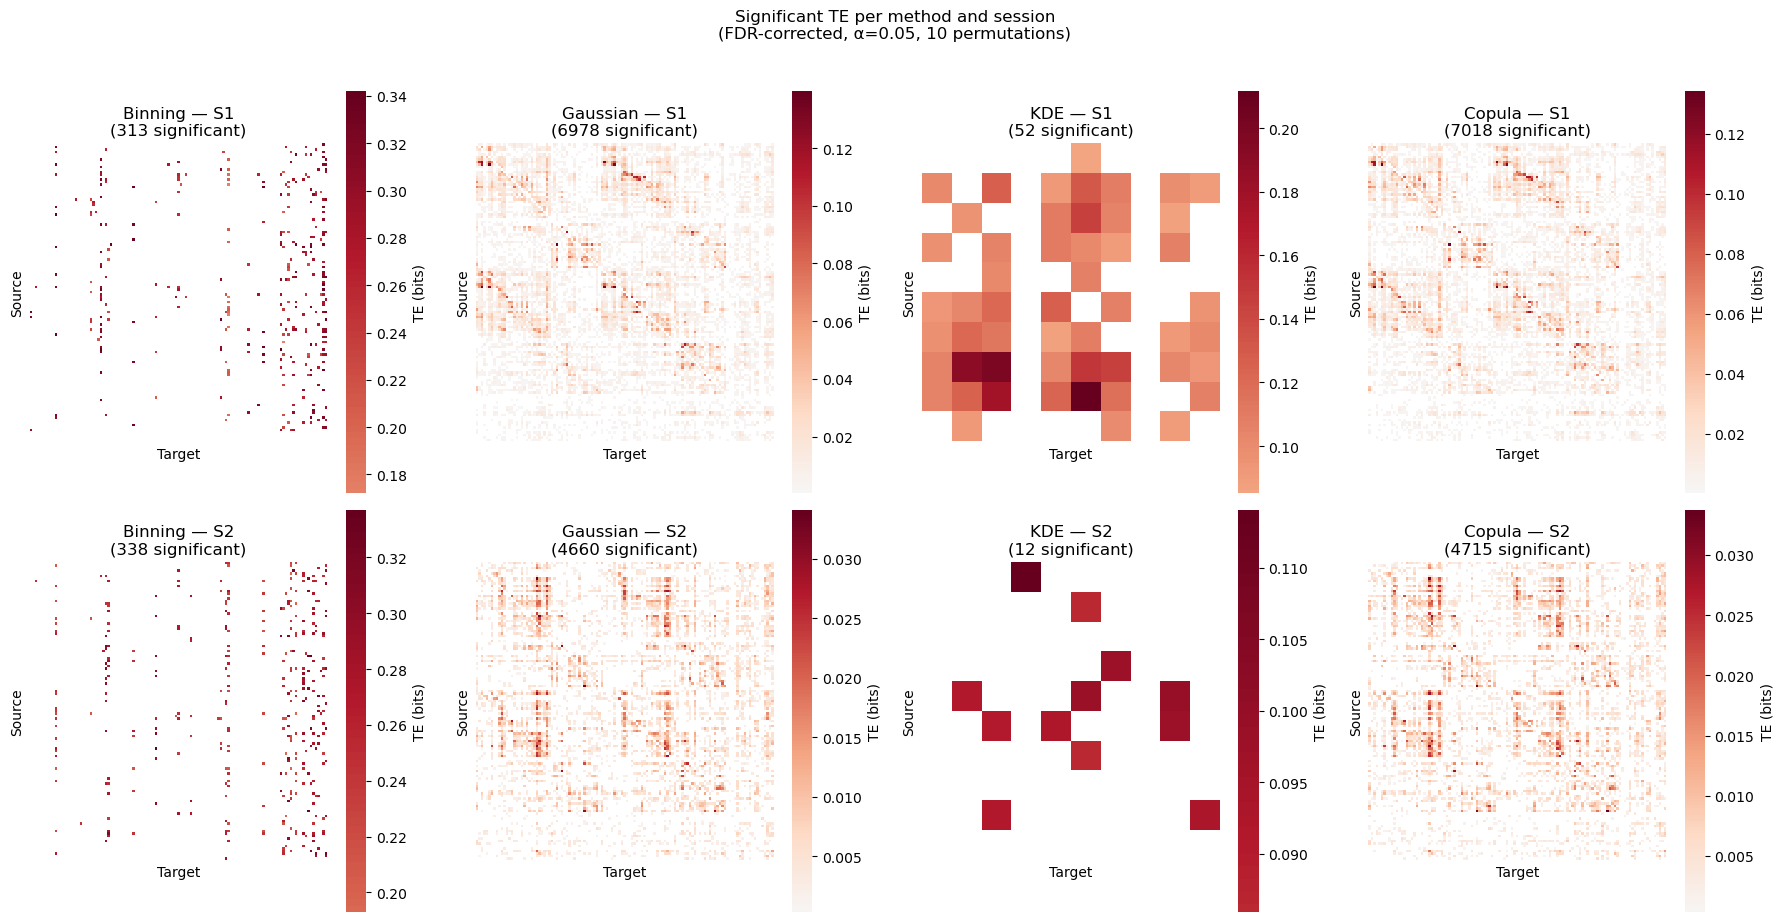

Robust connections surviving both sessions (FDR α=0.05, 10 permutations):
Method           S1     S2   Both
--------------------------------
Binning         313    338     29
Gaussian       6978   4660   3187
KDE              52     12      8
Copula         7018   4715   3277


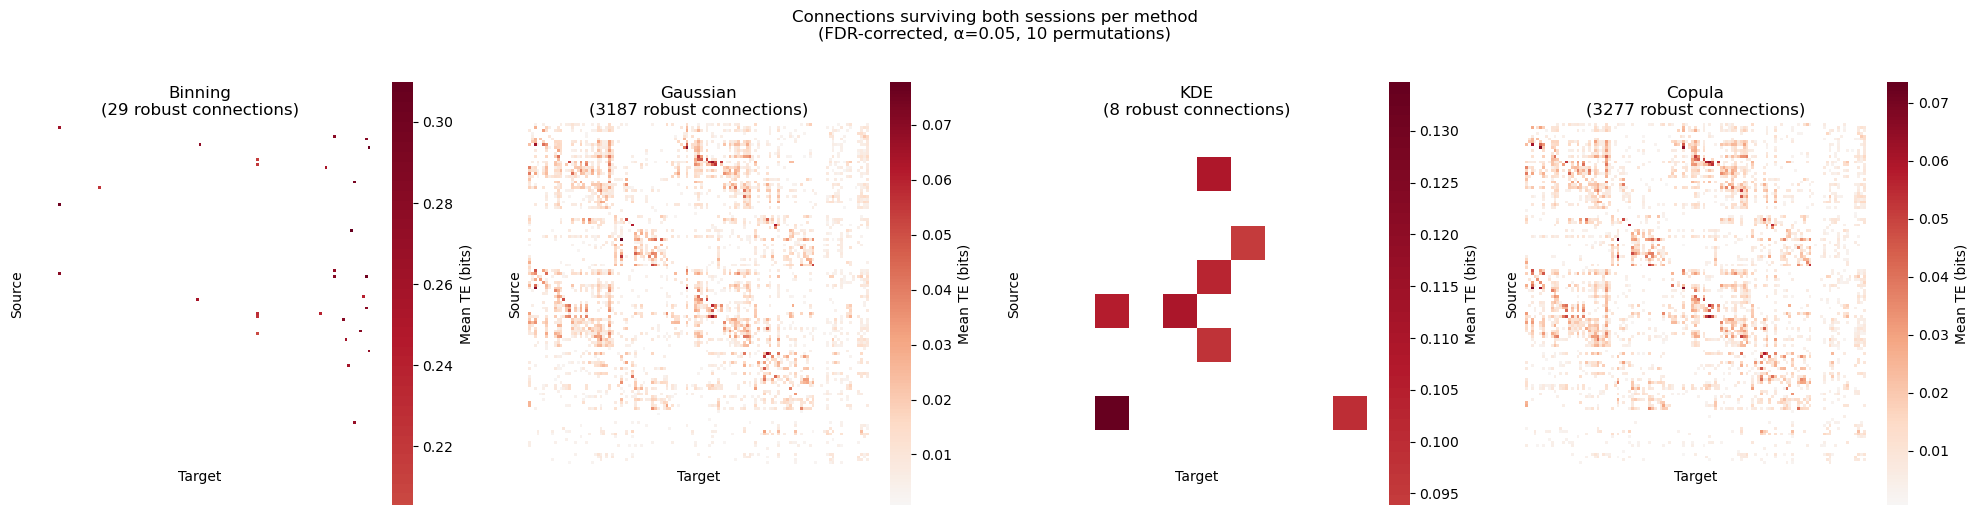

'\nfor sig1, sig2, te1, te2, name in methods_grid:\n    robust = sig1 & sig2\n    np.fill_diagonal(robust, False)\n    rows, cols = np.where(robust)\n\n    print(f"\n{\'=\'*50}")\n    print(f"{name} — {robust.sum()} connections surviving both sessions:")\n    print(f"{\'Source\':>8} {\'Target\':>8} | {\'TE S1\':>10} {\'TE S2\':>10} {\'Mean TE\':>10}")\n    print("-" * 50)\n    for i, j in zip(rows, cols):\n        mean_te = (te1[i,j] + te2[i,j]) / 2\n        print(f"{i:>8} {j:>8} | {te1[i,j]:>10.4f} {te2[i,j]:>10.4f} {mean_te:>10.4f}")\n'

In [12]:
# --------------------------------------------------
# Robust mask: significant in BOTH sessions
# for Gaussian and Copula (our most reliable methods)
# --------------------------------------------------
robust_mask = sig_gauss_1 & sig_gauss_2 & sig_copula_1 & sig_copula_2
np.fill_diagonal(robust_mask, False)

print(f"Significant connections (FDR α={alpha}, {n_perms} permutations):")
print(f"  Gaussian  — S1: {sig_gauss_1.sum():4d},  S2: {sig_gauss_2.sum():4d}")
print(f"  Copula    — S1: {sig_copula_1.sum():4d},  S2: {sig_copula_2.sum():4d}")
print(f"  Binning   — S1: {sig_bin_1.sum():4d},  S2: {sig_bin_2.sum():4d}")
print(f"  KDE       — S1: {sig_kde_1.sum():4d},  S2: {sig_kde_2.sum():4d}")
print(f"  Robust (Gauss + Copula, both sessions): {robust_mask.sum()}")

# --------------------------------------------------
# Significant connections per method, per session
# 2 rows (sessions) x 4 columns (methods)
# --------------------------------------------------
sig_grid = [
    # Session 1
    (sig_bin_1,    "Binning — S1"),
    (sig_gauss_1,  "Gaussian — S1"),
    (sig_kde_1,    "KDE — S1"),
    (sig_copula_1, "Copula — S1"),
    # Session 2
    (sig_bin_2,    "Binning — S2"),
    (sig_gauss_2,  "Gaussian — S2"),
    (sig_kde_2,    "KDE — S2"),
    (sig_copula_2, "Copula — S2"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (mat, title) in zip(axes.flat, sig_grid):
    sns.heatmap(mat.astype(int), ax=ax, cmap="Blues", vmin=0, vmax=1,
                square=True, cbar=False,
                xticklabels=False, yticklabels=False)
    ax.set_title(f"{title}\n({mat.sum()} connections)")
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")

plt.suptitle(f"Significant connections per method and session\n"
             f"(FDR-corrected, α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# TEs per method, per session
# 2 rows (sessions) x 4 columns (methods)
# --------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

sig_grid = [
    # Session 1
    (sig_bin_1,    TE_real_bin_1,    "Binning — S1"),
    (sig_gauss_1,  TE_real_gauss_1,  "Gaussian — S1"),
    (sig_kde_1,    TE_real_kde_1,    "KDE — S1"),
    (sig_copula_1, TE_real_copula_1, "Copula — S1"),
    # Session 2
    (sig_bin_2,    TE_real_bin_2,    "Binning — S2"),
    (sig_gauss_2,  TE_real_gauss_2,  "Gaussian — S2"),
    (sig_kde_2,    TE_real_kde_2,    "KDE — S2"),
    (sig_copula_2, TE_real_copula_2, "Copula — S2"),
]

for ax, (sig, te, title) in zip(axes.flat, sig_grid):
    # Keep real TE values only where significant, NaN elsewhere
    te_masked = np.where(sig, te, np.nan)
    sns.heatmap(te_masked, ax=ax, cmap="RdBu_r",
                center=0, square=True,
                cbar_kws={"label": "TE (bits)"},
                xticklabels=False, yticklabels=False)
    ax.set_title(f"{title}\n({sig.sum()} significant)")
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")

plt.suptitle(f"Significant TE per method and session\n"
             f"(FDR-corrected, α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Robust TEs across sessions (averaged between sessions)
# 4 columns (methods)
# --------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

methods_grid = [
    (sig_bin_1,    sig_bin_2,    TE_real_bin_1,    TE_real_bin_2,    "Binning"),
    (sig_gauss_1,  sig_gauss_2,  TE_real_gauss_1,  TE_real_gauss_2,  "Gaussian"),
    (sig_kde_1,    sig_kde_2,    TE_real_kde_1,    TE_real_kde_2,    "KDE"),
    (sig_copula_1, sig_copula_2, TE_real_copula_1, TE_real_copula_2, "Copula"),
]

# --- Summary ---
print(f"Robust connections surviving both sessions (FDR α={alpha}, {n_perms} permutations):")
print(f"{'Method':<12} {'S1':>6} {'S2':>6} {'Both':>6}")
print("-" * 32)
for sig1, sig2, te1, te2, name in methods_grid:
    robust = sig1 & sig2
    np.fill_diagonal(robust, False)
    print(f"{name:<12} {sig1.sum():>6} {sig2.sum():>6} {robust.sum():>6}")

# --- Heatmaps ---
for ax, (sig1, sig2, te1, te2, name) in zip(axes, methods_grid):
    robust = sig1 & sig2
    np.fill_diagonal(robust, False)
    avg_te = np.where(robust, (te1 + te2) / 2, np.nan)

    sns.heatmap(avg_te, ax=ax, cmap="RdBu_r", center=0, square=True,
                cbar_kws={"label": "Mean TE (bits)"},
                xticklabels=False, yticklabels=False)
    ax.set_title(f"{name}\n({robust.sum()} robust connections)")
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")

plt.suptitle(f"Connections surviving both sessions per method\n"
             f"(FDR-corrected, α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# --- Detailed pair list (comment out if not needed) ---
"""
for sig1, sig2, te1, te2, name in methods_grid:
    robust = sig1 & sig2
    np.fill_diagonal(robust, False)
    rows, cols = np.where(robust)

    print(f"\n{'='*50}")
    print(f"{name} — {robust.sum()} connections surviving both sessions:")
    print(f"{'Source':>8} {'Target':>8} | {'TE S1':>10} {'TE S2':>10} {'Mean TE':>10}")
    print("-" * 50)
    for i, j in zip(rows, cols):
        mean_te = (te1[i,j] + te2[i,j]) / 2
        print(f"{i:>8} {j:>8} | {te1[i,j]:>10.4f} {te2[i,j]:>10.4f} {mean_te:>10.4f}")
"""

After applying permutation testing and FDR correction, we focus on **statistically significant Transfer Entropy values**.

Several key differences emerge across methods:

- **Gaussian and Copula** detect a very large number of significant links:
  - the resulting networks are **dense**
  - many interactions are statistically significant
  - this suggests strong sensitivity to **linear correlations** and possibly **shared or indirect effects**

- **KDE** detects only a small number of significant links:
  - the resulting network is **very sparse**
  - only the strongest interactions survive
  - weaker dependencies are likely filtered out

- **Binning** provides intermediate results:
  - results may still be affected by **discretization bias** (which KDE does not have, while it depends on some other parameters)

#### Consistency across sessions

- The number of significant links varies between sessions, especially for Gaussian and Copula methods

- However, some connections are consistently detected in both sessions, indicating potential **robust interactions**

#### Robust connections

To improve reliability, we define a **robust connectivity mask** by selecting only links that are:

- significant in **both sessions**
- detected by both **Gaussian and Copula methods**

$$
\text{robust mask} = \text{Gauss}_1 \;\land\; \text{Gauss}_2 \;\land\; \text{Copula}_1 \;\land\; \text{Copula}_2
$$

This selection removes:
- links driven by **noise or finite-sample effects**
- links that are **not reproducible across sessions**
- links that are **method-dependent**

#### Interpretation

- Raw TE matrices contain many apparent interactions, but a large fraction depends on the estimation method

- After statistical testing and cross-validation, only a subset of links remains:
  - these are more likely to represent **genuine directed dependencies**

- The agreement between Gaussian and Copula suggests that:
  - a significant part of the detected structure is **consistent with linear or monotonic dependencies**

Overall, combining:
- statistical significance,
- cross-session consistency,
- and cross-method agreement

allows us to extract a **_possibly_ stable and meaningful connectivity pattern** from noisy data.

# **CONSENSUS MATRIX**

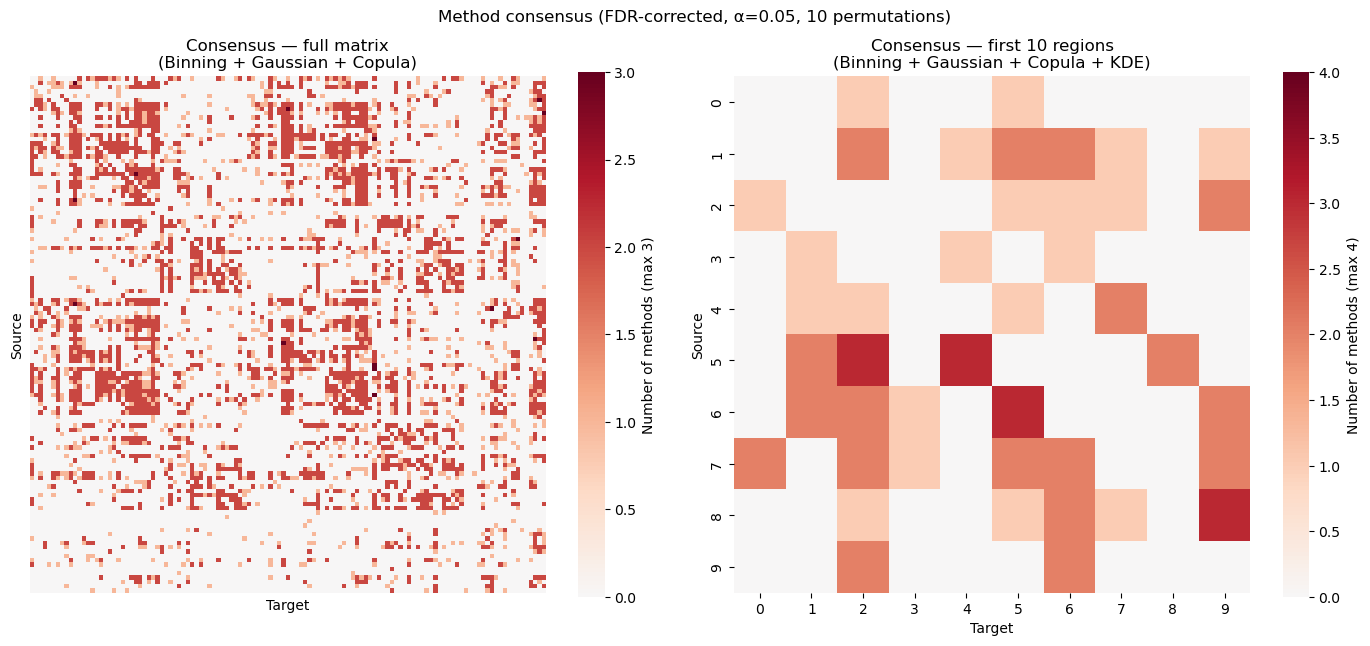

Full matrix (3 methods, 119 regions):
  0 methods agree: 10271 links
  1 methods agree: 1302 links
  2 methods agree: 2573 links
  3 methods agree:   15 links

10-region submatrix (4 methods):
  0 methods agree:   58 links
  1 methods agree:   20 links
  2 methods agree:   18 links
  3 methods agree:    4 links
  4 methods agree:    0 links


In [13]:
# --------------------------------------------------
# Consensus matrix: two versions
# Left:  full 119x119, Gauss + Copula + Binning (3 methods)
# Right: 10x10 submatrix, all 4 methods including KDE
# --------------------------------------------------

# --- Left: 119x119, 3 methods ---
robust_bin    = sig_bin_1    & sig_bin_2;    np.fill_diagonal(robust_bin,    False)
robust_gauss  = sig_gauss_1  & sig_gauss_2;  np.fill_diagonal(robust_gauss,  False)
robust_copula = sig_copula_1 & sig_copula_2; np.fill_diagonal(robust_copula, False)
robust_kde    = sig_kde_1    & sig_kde_2;    np.fill_diagonal(robust_kde,    False)

consensus_full = (robust_bin.astype(int) +
                  robust_gauss.astype(int) +
                  robust_copula.astype(int))

# --- Right: 10x10, 4 methods ---
n = kde_regions
consensus_10 = (robust_bin[:n, :n].astype(int) +
                robust_gauss[:n, :n].astype(int) +
                robust_copula[:n, :n].astype(int) +
                robust_kde.astype(int))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(consensus_full, ax=axes[0], cmap="RdBu_r", center=0,  vmin=0, vmax=3,
            square=True, cbar_kws={"label": "Number of methods (max 3)"},
            xticklabels=False, yticklabels=False)
axes[0].set_title("Consensus — full matrix\n(Binning + Gaussian + Copula)")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Source")

sns.heatmap(consensus_10, ax=axes[1], cmap="RdBu_r", center=0, vmin=0, vmax=4,
            square=True, cbar_kws={"label": "Number of methods (max 4)"},
            xticklabels=range(n), yticklabels=range(n))
axes[1].set_title("Consensus — first 10 regions\n(Binning + Gaussian + Copula + KDE)")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Source")

plt.suptitle(f"Method consensus (FDR-corrected, α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# --- Summary ---
print("Full matrix (3 methods, 119 regions):")
for n_agree in range(4):
    print(f"  {n_agree} methods agree: {np.sum(consensus_full == n_agree):4d} links")

print(f"\n10-region submatrix (4 methods):")
for n_agree in range(5):
    print(f"  {n_agree} methods agree: {np.sum(consensus_10 == n_agree):4d} links")

# **LAG SWEEP**

In [15]:
# LAG SWEEP — only robust average-TE heatmaps per method
lags_to_test = [1, 2, 5, 10, 20]

for lag in lags_to_test:
    print(f"\n{'='*60}")
    print(f"LAG = {lag}")
    print(f"{'='*60}")

    # --------------------------------------------------
    # Recompute real TE matrices for this lag
    # --------------------------------------------------
    TE_real_gauss_1  = nlib.transfer_entropy_matrix(data1_mat,                   method="gauss", lag=lag)
    TE_real_gauss_2  = nlib.transfer_entropy_matrix(data2_mat,                   method="gauss", lag=lag)

    TE_real_copula_1 = nlib.transfer_entropy_matrix(data1_mat,                   method="gc",   lag=lag)
    TE_real_copula_2 = nlib.transfer_entropy_matrix(data2_mat,                   method="gc",   lag=lag)

    TE_real_bin_1    = nlib.transfer_entropy_matrix(data1_mat,                   method="binning",  lag=lag, n_bins=nbins)
    TE_real_bin_2    = nlib.transfer_entropy_matrix(data2_mat,                   method="binning",  lag=lag, n_bins=nbins)

    TE_real_kde_1    = nlib.transfer_entropy_matrix(data1_mat[:kde_regions, :],  method="kde",      lag=lag)
    TE_real_kde_2    = nlib.transfer_entropy_matrix(data2_mat[:kde_regions, :],  method="kde",      lag=lag)

    # --------------------------------------------------
    # Permutation tests
    # --------------------------------------------------
    sig_gauss_1,  _, _ = permutation_test_TE(
        data1_mat, TE_real_gauss_1,
        method="gauss", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )
    sig_gauss_2,  _, _ = permutation_test_TE(
        data2_mat, TE_real_gauss_2,
        method="gauss", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )

    sig_copula_1, _, _ = permutation_test_TE(
        data1_mat, TE_real_copula_1,
        method="gc", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )
    sig_copula_2, _, _ = permutation_test_TE(
        data2_mat, TE_real_copula_2,
        method="gc", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )

    sig_bin_1, _, _ = permutation_test_TE(
        data1_mat, TE_real_bin_1,
        method="binning", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag, n_bins=nbins
    )
    sig_bin_2, _, _ = permutation_test_TE(
        data2_mat, TE_real_bin_2,
        method="binning", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag, n_bins=nbins
    )

    sig_kde_1, _, _ = permutation_test_TE(
        data1_mat[:kde_regions, :], TE_real_kde_1,
        method="kde", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )
    sig_kde_2, _, _ = permutation_test_TE(
        data2_mat[:kde_regions, :], TE_real_kde_2,
        method="kde", n_perms=n_perms, alpha=alpha, fdr=True, lag=lag
    )

    # --------------------------------------------------
    # Methods list
    # --------------------------------------------------
    methods_grid = [
        (sig_bin_1,    sig_bin_2,    TE_real_bin_1,    TE_real_bin_2,    "Binning"),
        (sig_gauss_1,  sig_gauss_2,  TE_real_gauss_1,  TE_real_gauss_2,  "Gaussian"),
        (sig_kde_1,    sig_kde_2,    TE_real_kde_1,    TE_real_kde_2,    "KDE"),
        (sig_copula_1, sig_copula_2, TE_real_copula_1, TE_real_copula_2, "Copula"),
    ]

    # --------------------------------------------------
    # Plot only robust average TE heatmaps
    # --------------------------------------------------
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for ax, (sig1, sig2, te1, te2, name) in zip(axes, methods_grid):
        robust = sig1 & sig2
        np.fill_diagonal(robust, False)

        avg_te = np.where(robust, (te1 + te2) / 2, np.nan)

        sns.heatmap(
            avg_te,
            ax=ax,
            cmap="RdBu_r",
            center=0,
            square=True,
            cbar_kws={"label": "Mean TE (bits)"},
            xticklabels=False,
            yticklabels=False
        )

        ax.set_title(f"{name}\n({robust.sum()} robust links)")
        ax.set_xlabel("Target")
        ax.set_ylabel("Source")

    plt.suptitle(
        f"Average TE across datasets, masked by significance in both sessions — lag={lag}\n"
        f"(FDR-corrected, α={alpha}, {n_perms} permutations)",
        y=1.03
    )
    plt.tight_layout()
    plt.show()


LAG = 1
  [gauss] shuffle 0/10...
  → 7028 significant connections (FDR-corrected, α=0.05)
  [gauss] shuffle 0/10...
  → 7016 significant connections (FDR-corrected, α=0.05)
  [gc] shuffle 0/10...
  → 6983 significant connections (FDR-corrected, α=0.05)
  [gc] shuffle 0/10...


KeyboardInterrupt: 